* If you're running this on Google Colab, please uncomment and run the cell below.

In [14]:
!git clone https://github.com/stnamjef/SPINN.git
%cd SPINN

Cloning into 'SPINN'...
remote: Enumerating objects: 256, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 256 (delta 20), reused 16 (delta 16), pack-reused 223 (from 2)
Receiving objects: 100% (256/256), 13.74 MiB | 19.04 MiB/s, done.
Resolving deltas: 100% (69/69), done.
/content/SPINN/SPINN/SPINN


In [15]:
!pip install optax
!pip install flax

In [16]:
%matplotlib inline
import os
import time
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
from tqdm import trange
from jax import jvp, value_and_grad
from flax import linen as nn
from typing import Sequence
from functools import partial

## 1. SPINN

In [17]:
# forward function
class SPINN(nn.Module):
    features: Sequence[int]

    @nn.compact
    def __call__(self, x, y, z):
        inputs, outputs = [x, y, z], []
        init = nn.initializers.glorot_normal()
        for X in inputs:
            for fs in self.features[:-1]:
                X = nn.Dense(fs, kernel_init=init)(X)
                X = nn.activation.tanh(X)
            X = nn.Dense(self.features[-1], kernel_init=init)(X)
            outputs += [jnp.transpose(X, (1, 0))]
        xy = jnp.einsum('fx, fy->fxy', outputs[0], outputs[1])
        return jnp.einsum('fxy, fz->xyz', xy, outputs[-1])


# hessian-vector product
def hvp_fwdfwd(f, primals, tangents, return_primals=False):
    g = lambda primals: jvp(f, (primals,), tangents)[1]
    primals_out, tangents_out = jvp(g, primals, tangents)
    if return_primals:
        return primals_out, tangents_out
    else:
        return tangents_out


# loss function
def spinn_loss_klein_gordon3d(apply_fn, *train_data):
    def residual_loss(params, t, x, y, source_term):
        # calculate u
        u = apply_fn(params, t, x, y)
        # tangent vector dx/dx
        # assumes t, x, y have same shape (very important)
        v = jnp.ones(t.shape)
        # 2nd derivatives of u
        utt = hvp_fwdfwd(lambda t: apply_fn(params, t, x, y), (t,), (v,))
        uxx = hvp_fwdfwd(lambda x: apply_fn(params, t, x, y), (x,), (v,))
        uyy = hvp_fwdfwd(lambda y: apply_fn(params, t, x, y), (y,), (v,))
        return jnp.mean((utt - uxx - uyy + u**2 - source_term)**2)

    def initial_loss(params, t, x, y, u):
        return jnp.mean((apply_fn(params, t, x, y) - u)**2)

    def boundary_loss(params, t, x, y, u):
        loss = 0.
        for i in range(4):
            loss += (1/4.) * jnp.mean((apply_fn(params, t[i], x[i], y[i]) - u[i])**2)
        return loss

    # unpack data
    tc, xc, yc, uc, ti, xi, yi, ui, tb, xb, yb, ub = train_data

    # isolate loss function from redundant arguments
    fn = lambda params: residual_loss(params, tc, xc, yc, uc) + \
                        initial_loss(params, ti, xi, yi, ui) + \
                        boundary_loss(params, tb, xb, yb, ub)

    return fn


# optimizer step function
@partial(jax.jit, static_argnums=(0,))
def update_model(optim, gradient, params, state):
    updates, state = optim.update(gradient, state)
    params = optax.apply_updates(params, updates)
    return params, state

## 2. Data generator

In [18]:
# 2d time-dependent klein-gordon exact u
def _klein_gordon3d_exact_u(t, x, y):
    return (x + y) * jnp.cos(2*t) + (x * y) * jnp.sin(2*t)


# 2d time-dependent klein-gordon source term
def _klein_gordon3d_source_term(t, x, y):
    u = _klein_gordon3d_exact_u(t, x, y)
    return u**2 - 4*u


# train data
def spinn_train_generator_klein_gordon3d(nc, key):
    keys = jax.random.split(key, 3)
    # collocation points
    tc = jax.random.uniform(keys[0], (nc, 1), minval=0., maxval=10.)
    xc = jax.random.uniform(keys[1], (nc, 1), minval=-1., maxval=1.)
    yc = jax.random.uniform(keys[2], (nc, 1), minval=-1., maxval=1.)
    tc_mesh, xc_mesh, yc_mesh = jnp.meshgrid(tc.ravel(), xc.ravel(), yc.ravel(), indexing='ij')
    uc = _klein_gordon3d_source_term(tc_mesh, xc_mesh, yc_mesh)
    # initial points
    ti = jnp.zeros((1, 1))
    xi = xc
    yi = yc
    ti_mesh, xi_mesh, yi_mesh = jnp.meshgrid(ti.ravel(), xi.ravel(), yi.ravel(), indexing='ij')
    ui = _klein_gordon3d_exact_u(ti_mesh, xi_mesh, yi_mesh)
    # boundary points (hard-coded)
    tb = [tc, tc, tc, tc]
    xb = [jnp.array([[-1.]]), jnp.array([[1.]]), xc, xc]
    yb = [yc, yc, jnp.array([[-1.]]), jnp.array([[1.]])]
    ub = []
    for i in range(4):
        tb_mesh, xb_mesh, yb_mesh = jnp.meshgrid(tb[i].ravel(), xb[i].ravel(), yb[i].ravel(), indexing='ij')
        ub += [_klein_gordon3d_exact_u(tb_mesh, xb_mesh, yb_mesh)]
    return tc, xc, yc, uc, ti, xi, yi, ui, tb, xb, yb, ub


# test data
def spinn_test_generator_klein_gordon3d(nc_test):
    t = jnp.linspace(0, 10, nc_test)
    x = jnp.linspace(-1, 1, nc_test)
    y = jnp.linspace(-1, 1, nc_test)
    t = jax.lax.stop_gradient(t)
    x = jax.lax.stop_gradient(x)
    y = jax.lax.stop_gradient(y)
    tm, xm, ym = jnp.meshgrid(t, x, y, indexing='ij')
    u_gt = _klein_gordon3d_exact_u(tm, xm, ym)
    t = t.reshape(-1, 1)
    x = x.reshape(-1, 1)
    y = y.reshape(-1, 1)
    return t, x, y, u_gt, tm, xm, ym

## 3. Utils

In [19]:
def relative_l2(u, u_gt):
    return jnp.linalg.norm(u-u_gt) / jnp.linalg.norm(u_gt)

def plot_klein_gordon3d(t, x, y, u):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(t, x, y, c=u, s=0.5, cmap='seismic')
    ax.set_title('U(t, x, y)', fontsize=20)
    ax.set_xlabel('t', fontsize=18, labelpad=10)
    ax.set_ylabel('x', fontsize=18, labelpad=10)
    ax.set_zlabel('y', fontsize=18, labelpad=10)
    plt.show()

## 4. Main function

In [20]:
def main(NC, NI, NB, NC_TEST, SEED, LR, EPOCHS, N_LAYERS, FEATURES, LOG_ITER):
    # force jax to use one device
    os.environ["CUDA_VISIBLE_DEVICES"]="0"
    os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]="false"

    # random key
    key = jax.random.PRNGKey(SEED)
    key, subkey = jax.random.split(key, 2)

    # feature sizes
    feat_sizes = tuple(FEATURES for _ in range(N_LAYERS))

    # make & init model
    model = SPINN(feat_sizes)
    params = model.init(subkey, jnp.ones((NC, 1)), jnp.ones((NC, 1)), jnp.ones((NC, 1)))

    # optimizer
    optim = optax.adam(LR)
    state = optim.init(params)

    # dataset
    key, subkey = jax.random.split(key, 2)
    train_data = spinn_train_generator_klein_gordon3d(NC, subkey)
    t, x, y, u_gt, tm, xm, ym = spinn_test_generator_klein_gordon3d(NC_TEST)

    # forward & loss function
    apply_fn = jax.jit(model.apply)
    loss_fn = spinn_loss_klein_gordon3d(apply_fn, *train_data)

    @jax.jit
    def train_one_step(params, state):
        # compute loss and gradient
        loss, gradient = value_and_grad(loss_fn)(params)
        # update state
        params, state = update_model(optim, gradient, params, state)
        return loss, params, state

    start = time.time()
    for e in trange(1, EPOCHS+1):
        # single run
        loss, params, state = train_one_step(params, state)
        if e % LOG_ITER == 0:
            u = apply_fn(params, t, x, y)
            error = relative_l2(u, u_gt)
            print(f'Epoch: {e}/{EPOCHS} --> loss: {loss:.8f}, error: {error:.8f}')
    end = time.time()
    print(f'Runtime: {((end-start)/EPOCHS*1000):.2f} ms/iter.')

    print('Solution:')
    u = apply_fn(params, t, x, y)
    plot_klein_gordon3d(tm, xm, ym, u)

## 5. Run!

 50%|█████     | 25115/50000 [00:48<01:06, 374.18it/s]

Epoch: 25000/50000 --> loss: 0.00451630, error: 0.02674565


100%|██████████| 50000/50000 [01:27<00:00, 568.95it/s]


Epoch: 50000/50000 --> loss: 0.00008878, error: 0.00333462
Runtime: 1.76 ms/iter.
Solution:


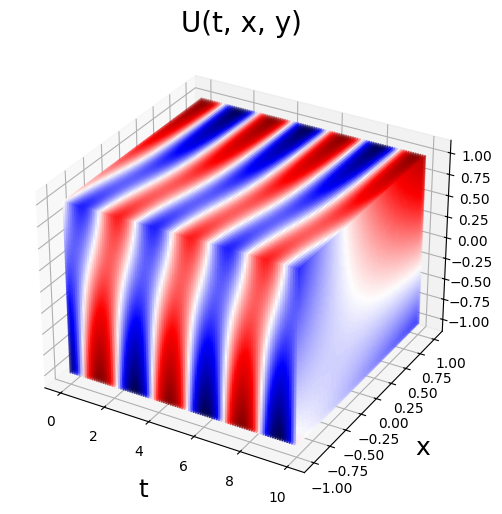

In [21]:
main(NC=64, NI=64, NB=64, NC_TEST=100, SEED=444, LR=1e-3, EPOCHS=50000, N_LAYERS=4, FEATURES=64, LOG_ITER=25000)

In [22]:
!python diffusion3d.py

/content/SPINN/SPINN/SPINN/utils/visualizer.py:201: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_title(f'Reference $\omega(t={jnp.round(t[0][0], 1):.2f}, x, y)$', fontsize=15)
/content/SPINN/SPINN/SPINN/utils/visualizer.py:208: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_title(f'Predicted $\omega(t={jnp.round(t[0][0], 1):.2f}, x, y)$', fontsize=15)
 20% 9986/50000 [00:41<01:51, 358.50it/s]Epoch: 10000/50000 --> total loss: 0.00000340, error: 0.00736402, best error 0.00734514
 40% 19981/50000 [01:11<01:24, 355.04it/s]Epoch: 20000/50000 --> total loss: 0.00000174, error: 0.00589858, best error 0.00493302
 60% 29992/50000 [01:41<00:55, 361.77it/s]Epoch: 30000/50000 --> total loss: 0.00000052, error: 0.00450330, best error 0.00401526
 80% 39965/50000 [02:11<00:28, 356.57it/s]Epoch: 40000/50000 --> total loss: 0.00000025, error: 0.00417977, best error 0.00390403
100% 49989/50000 [02:40<00:00, 354.21it/s]Epoch: 50000/50000 --> total loss: 0.00000052, error: 0.00381616, bes

In [23]:
!find . -name "*.png" -o -name "*.pdf"

./assets/architecture.png
./results/diffusion3d/spinn/nc64_nl3_fs128_lr0.001_s111_r128_modified_mlp/vis/50000/pred_0.8.png
./results/diffusion3d/spinn/nc64_nl3_fs128_lr0.001_s111_r128_modified_mlp/vis/50000/pred_0.2.png
./results/diffusion3d/spinn/nc64_nl3_fs128_lr0.001_s111_r128_modified_mlp/vis/50000/pred_0.7.png
./results/diffusion3d/spinn/nc64_nl3_fs128_lr0.001_s111_r128_modified_mlp/vis/50000/pred_0.6.png
./results/diffusion3d/spinn/nc64_nl3_fs128_lr0.001_s111_r128_modified_mlp/vis/50000/pred_0.1.png
./results/diffusion3d/spinn/nc64_nl3_fs128_lr0.001_s111_r128_modified_mlp/vis/50000/pred_1.0.png
./results/diffusion3d/spinn/nc64_nl3_fs128_lr0.001_s111_r128_modified_mlp/vis/50000/pred_0.0.png
./results/diffusion3d/spinn/nc64_nl3_fs128_lr0.001_s111_r128_modified_mlp/vis/50000/pred_0.9.png
./results/diffusion3d/spinn/nc64_nl3_fs128_lr0.001_s111_r128_modified_mlp/vis/50000/pred_0.4.png
./results/diffusion3d/spinn/nc64_nl3_fs128_lr0.001_s111_r128_modified_mlp/vis/50000/pred_0.3.png
./re

In [24]:
!python flow_mixing3d.py

 10% 4977/50000 [00:24<01:52, 401.75it/s]Epoch: 5000/50000 --> total loss: 0.00548357, error: 0.12401026, best error 0.13148823
 20% 9987/50000 [00:37<01:43, 388.47it/s]Epoch: 10000/50000 --> total loss: 0.00393391, error: 0.07570037, best error 0.07590535
 30% 14987/50000 [00:51<02:03, 284.16it/s]Epoch: 15000/50000 --> total loss: 0.00190512, error: 0.04860173, best error 0.04864841
 40% 19994/50000 [01:04<01:24, 356.27it/s]Epoch: 20000/50000 --> total loss: 0.00145749, error: 0.03617930, best error 0.03641765
 50% 24968/50000 [01:17<01:01, 409.64it/s]Epoch: 25000/50000 --> total loss: 0.00092808, error: 0.02824821, best error 0.02821359
 60% 29984/50000 [01:31<00:51, 385.29it/s]Epoch: 30000/50000 --> total loss: 0.00082533, error: 0.02333119, best error 0.02507607
 70% 34980/50000 [01:44<00:39, 382.40it/s]Epoch: 35000/50000 --> total loss: 0.00063854, error: 0.02246628, best error 0.01817632
 80% 39996/50000 [01:57<00:24, 405.50it/s]Epoch: 40000/50000 --> total loss: 0.00013984, erro

In [25]:
!python helmholtz3d.py

 20% 9977/50000 [00:44<02:08, 312.57it/s]Epoch: 10000/50000 --> total loss: 0.82163399, error: 0.05019759, best error 0.04966941
 40% 19993/50000 [01:16<01:37, 308.12it/s]Epoch: 20000/50000 --> total loss: 0.80697334, error: 0.03980761, best error 0.04281917
 60% 29991/50000 [01:49<01:22, 243.24it/s]Epoch: 30000/50000 --> total loss: 9.77370548, error: 0.04916086, best error 0.04140961
 80% 39996/50000 [02:21<00:29, 336.36it/s]Epoch: 40000/50000 --> total loss: 0.13489407, error: 0.03399559, best error 0.03294546
100% 49982/50000 [02:52<00:00, 346.41it/s]Epoch: 50000/50000 --> total loss: 0.38868284, error: 0.03022735, best error 0.02949603
visualizing solution...
100% 50000/50000 [03:10<00:00, 262.55it/s]
Runtime --> total: 178.52sec (3.57ms/iter.)


In [26]:
!python klein_gordon3d.py

 20% 9965/50000 [00:43<01:48, 370.53it/s]Epoch: 10000/50000 --> total loss: 0.00066998, error: 0.01134092, best error 0.01179488
 40% 19981/50000 [01:14<01:25, 351.67it/s]Epoch: 20000/50000 --> total loss: 0.00034074, error: 0.00401144, best error 0.00303039
 60% 29974/50000 [01:45<01:14, 269.02it/s]Epoch: 30000/50000 --> total loss: 0.00019776, error: 0.00317836, best error 0.00135370
 80% 39975/50000 [02:15<00:26, 381.53it/s]Epoch: 40000/50000 --> total loss: 0.00013049, error: 0.00162389, best error 0.00116654
100% 49982/50000 [02:45<00:00, 339.24it/s]Epoch: 50000/50000 --> total loss: 0.00019186, error: 0.00232100, best error 0.00107337
visualizing solution...
100% 50000/50000 [03:04<00:00, 271.74it/s]
Runtime --> total: 170.80sec (3.42ms/iter.)


In [27]:
!python klein_gordon4d.py

  2% 990/50000 [00:30<16:31, 49.42it/s]Epoch: 1000/50000 --> total loss: 7.17180395, error: 1.24354982, best error 1.06441808
  4% 1990/50000 [00:50<16:09, 49.51it/s]Epoch: 2000/50000 --> total loss: 7.39010763, error: 1.16298926, best error 1.06441808
  6% 2990/50000 [01:10<15:48, 49.57it/s]Epoch: 3000/50000 --> total loss: 6.89386654, error: 1.07703054, best error 0.97250515
  8% 3990/50000 [01:30<15:02, 50.97it/s]Epoch: 4000/50000 --> total loss: 3.16658473, error: 1.18394375, best error 1.10258222
 10% 4990/50000 [01:50<15:07, 49.58it/s]Epoch: 5000/50000 --> total loss: 3.64102507, error: 1.17768729, best error 1.09148693
 12% 5990/50000 [02:10<14:50, 49.40it/s]Epoch: 6000/50000 --> total loss: 5.15379286, error: 1.08059609, best error 1.17007220
 14% 6990/50000 [02:30<14:27, 49.55it/s]Epoch: 7000/50000 --> total loss: 9.67140579, error: 1.08294940, best error 1.17007220
 16% 7990/50000 [02:50<14:07, 49.56it/s]Epoch: 8000/50000 --> total loss: 3.56209612, error: 1.11667967, best er

In [28]:
!python navier_stokes3d.py

Traceback (most recent call last):
  File "/content/SPINN/SPINN/SPINN/navier_stokes3d.py", line 130, in <module>
    apply_fn, params = setup_networks(args, subkey)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/SPINN/SPINN/SPINN/utils/training_utils.py", line 51, in setup_networks
    jnp.ones((args.nt, 1)),
    ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_creation.py", line 139, in ones
    shape = canonicalize_shape(shape)
            ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_creation.py", line 46, in canonicalize_shape
    return core.canonicalize_shape(shape, context)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/core.py", line 2017, in canonicalize_shape
    raise _invalid_shape_error(shape, context)
TypeError: Shapes must be 1D sequences of concrete values of integer type, got (None, 1).


In [29]:
!python navier_stokes4d.py

compiling...
  2% 998/50000 [03:26<49:57, 16.35it/s]Epoch: 1000/50000 --> total loss: 1.53873563, error: 0.17622326, best error 0.16244224
  4% 1999/50000 [04:31<49:45, 16.08it/s]Epoch: 2000/50000 --> total loss: 0.40708715, error: 0.08602725, best error 0.10500815
  6% 2999/50000 [05:36<49:25, 15.85it/s]Epoch: 3000/50000 --> total loss: 0.75743091, error: 0.07583963, best error 0.06600779
  8% 3999/50000 [06:41<48:02, 15.96it/s]Epoch: 4000/50000 --> total loss: 0.21497487, error: 0.04352055, best error 0.03722277
 10% 4999/50000 [07:46<47:09, 15.91it/s]Epoch: 5000/50000 --> total loss: 0.05831398, error: 0.02395879, best error 0.03028825
 12% 5999/50000 [08:51<46:01, 15.93it/s]Epoch: 6000/50000 --> total loss: 0.06707652, error: 0.03524519, best error 0.02250978
 14% 6999/50000 [09:56<44:57, 15.94it/s]Epoch: 7000/50000 --> total loss: 0.04274134, error: 0.01959136, best error 0.01936679
 16% 7999/50000 [11:01<43:53, 15.95it/s]Epoch: 8000/50000 --> total loss: 0.01100384, error: 0.0118